In [ ]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=74e786869fc89d0f2c432b4554a645efc0b11b87847426e248df307bed086997
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


In [ ]:
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder.appName("Window").getOrCreate()

In [ ]:
df = spark.read.format('csv').option('header','True').option('inferSchema','True').load('/content/2010-12-01.csv')

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/content/2010-12-01.csv.

In [ ]:
from pyspark.sql.functions import window , col

In [ ]:
df.select(window(col('InvoiceDate'),'2 day'),'InvoiceDate').show()

+--------------------+-------------------+
|              window|        InvoiceDate|
+--------------------+-------------------+
|{2010-12-01 00:00...|2010-12-01 08:26:00|
|{2010-12-01 00:00...|2010-12-01 08:26:00|
|{2010-12-01 00:00...|2010-12-01 08:26:00|
|{2010-12-01 00:00...|2010-12-01 08:26:00|
|{2010-12-01 00:00...|2010-12-01 08:26:00|
|{2010-12-01 00:00...|2010-12-01 08:26:00|
|{2010-12-01 00:00...|2010-12-01 08:26:00|
|{2010-12-01 00:00...|2010-12-01 08:28:00|
|{2010-12-01 00:00...|2010-12-01 08:28:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
|{2010-12-01 00:00...|2010-12-01 08:34:00|
+----------

In [ ]:
df.show()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|   17850.0|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|   17850.0|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|2010-12-01 08:26:00|     7.65|   17850.0|United Kingdom|
|   536365|    21730|GLASS S

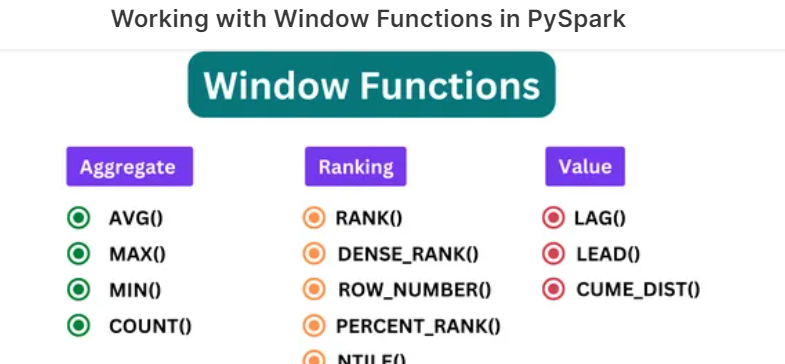

In [ ]:
employees = [
    (7369, "SMITH", "CLERK", "17-Dec-80", 800, 20, 10),
    (7499, "ALLEN", "SALESMAN", "20-Feb-81", 1600, 300, 30),
    (7521, "WARD", "SALESMAN", "22-Feb-81", 1250, 500, 30),
    (7566, "JONES", "MANAGER", "2-Apr-81", 2975, 0, 20),
    (7654, "MARTIN", "SALESMAN", "28-Sep-81", 1250, 1400, 30),
    (7698, "BLAKE", "MANAGER", "1-May-81", 2850, 0, 30),
    (7782, "CLARK", "MANAGER", "9-Jun-81", 2450, 0, 10),
    (7788, "SCOTT", "ANALYST", "19-Apr-87", 3000, 0, 20),
    (7629, "ALEX", "SALESMAN", "28-Sep-79", 1150, 1400, 30),
    (7839, "KING", "PRESIDENT", "17-Nov-81", 5000, 0, 10),
    (7844, "TURNER", "SALESMAN", "8-Sep-81", 1500, 0, 30),
    (7876, "ADAMS", "CLERK", "23-May-87", 1100, 0, 20)
]

In [ ]:
emp_df = spark.createDataFrame(employees,
           ["empno", "ename", "job", "hiredate", "sal", "comm", "deptno"])
emp_df.show()

+-----+------+---------+---------+----+----+------+
|empno| ename|      job| hiredate| sal|comm|deptno|
+-----+------+---------+---------+----+----+------+
| 7369| SMITH|    CLERK|17-Dec-80| 800|  20|    10|
| 7499| ALLEN| SALESMAN|20-Feb-81|1600| 300|    30|
| 7521|  WARD| SALESMAN|22-Feb-81|1250| 500|    30|
| 7566| JONES|  MANAGER| 2-Apr-81|2975|   0|    20|
| 7654|MARTIN| SALESMAN|28-Sep-81|1250|1400|    30|
| 7698| BLAKE|  MANAGER| 1-May-81|2850|   0|    30|
| 7782| CLARK|  MANAGER| 9-Jun-81|2450|   0|    10|
| 7788| SCOTT|  ANALYST|19-Apr-87|3000|   0|    20|
| 7629|  ALEX| SALESMAN|28-Sep-79|1150|1400|    30|
| 7839|  KING|PRESIDENT|17-Nov-81|5000|   0|    10|
| 7844|TURNER| SALESMAN| 8-Sep-81|1500|   0|    30|
| 7876| ADAMS|    CLERK|23-May-87|1100|   0|    20|
+-----+------+---------+---------+----+----+------+



In [ ]:
emp_df.printSchema()

root
 |-- empno: long (nullable = true)
 |-- ename: string (nullable = true)
 |-- job: string (nullable = true)
 |-- hiredate: string (nullable = true)
 |-- sal: long (nullable = true)
 |-- comm: long (nullable = true)
 |-- deptno: long (nullable = true)



Here we are creating a temporary view for the dataframes to do calcultion in sql also

In [ ]:
emp_df.createOrReplaceTempView('emp')

**Q1 Rank the salary within each department**

In [ ]:
rank_df = spark.sql(
        """SELECT empno, ename, job, deptno, sal,
        RANK() OVER (PARTITION BY deptno ORDER BY sal DESC) AS rank FROM emp""")
rank_df.show()

+-----+------+---------+------+----+----+
|empno| ename|      job|deptno| sal|rank|
+-----+------+---------+------+----+----+
| 7839|  KING|PRESIDENT|    10|5000|   1|
| 7782| CLARK|  MANAGER|    10|2450|   2|
| 7369| SMITH|    CLERK|    10| 800|   3|
| 7788| SCOTT|  ANALYST|    20|3000|   1|
| 7566| JONES|  MANAGER|    20|2975|   2|
| 7876| ADAMS|    CLERK|    20|1100|   3|
| 7698| BLAKE|  MANAGER|    30|2850|   1|
| 7499| ALLEN| SALESMAN|    30|1600|   2|
| 7844|TURNER| SALESMAN|    30|1500|   3|
| 7521|  WARD| SALESMAN|    30|1250|   4|
| 7654|MARTIN| SALESMAN|    30|1250|   4|
| 7629|  ALEX| SALESMAN|    30|1150|   6|
+-----+------+---------+------+----+----+



In [ ]:
from pyspark.sql import   Window

In [ ]:
from pyspark.sql.functions import rank,row_number,dense_rank

In [ ]:
windowSpec = Window.partitionBy(col('deptno')).orderBy(col('sal').desc())


In [ ]:
ranking_result_df = emp_df.select('empno', 'ename', 'job', 'deptno', 'sal',
            rank().over(windowSpec).alias('rank'))
ranking_result_df.show()

+-----+------+---------+------+----+----+
|empno| ename|      job|deptno| sal|rank|
+-----+------+---------+------+----+----+
| 7839|  KING|PRESIDENT|    10|5000|   1|
| 7782| CLARK|  MANAGER|    10|2450|   2|
| 7369| SMITH|    CLERK|    10| 800|   3|
| 7788| SCOTT|  ANALYST|    20|3000|   1|
| 7566| JONES|  MANAGER|    20|2975|   2|
| 7876| ADAMS|    CLERK|    20|1100|   3|
| 7698| BLAKE|  MANAGER|    30|2850|   1|
| 7499| ALLEN| SALESMAN|    30|1600|   2|
| 7844|TURNER| SALESMAN|    30|1500|   3|
| 7521|  WARD| SALESMAN|    30|1250|   4|
| 7654|MARTIN| SALESMAN|    30|1250|   4|
| 7629|  ALEX| SALESMAN|    30|1150|   6|
+-----+------+---------+------+----+----+



In [ ]:
ranking_result_df_row_number = emp_df.select('empno', 'ename', 'job', 'deptno', 'sal',
            row_number().over(windowSpec).alias('rank'))
ranking_result_df_row_number.show()

+-----+------+---------+------+----+----+
|empno| ename|      job|deptno| sal|rank|
+-----+------+---------+------+----+----+
| 7839|  KING|PRESIDENT|    10|5000|   1|
| 7782| CLARK|  MANAGER|    10|2450|   2|
| 7369| SMITH|    CLERK|    10| 800|   3|
| 7788| SCOTT|  ANALYST|    20|3000|   1|
| 7566| JONES|  MANAGER|    20|2975|   2|
| 7876| ADAMS|    CLERK|    20|1100|   3|
| 7698| BLAKE|  MANAGER|    30|2850|   1|
| 7499| ALLEN| SALESMAN|    30|1600|   2|
| 7844|TURNER| SALESMAN|    30|1500|   3|
| 7521|  WARD| SALESMAN|    30|1250|   4|
| 7654|MARTIN| SALESMAN|    30|1250|   5|
| 7629|  ALEX| SALESMAN|    30|1150|   6|
+-----+------+---------+------+----+----+



**Here in the above example we can also see the different use of rank and row_number**

** Dense rank the salary within each department.**

In [ ]:
dense_df = spark.sql(
        """SELECT empno, ename, job, deptno, sal,
        DENSE_RANK() OVER (PARTITION BY deptno ORDER BY sal DESC)
        AS dense_rank FROM emp""")
dense_df.show()

+-----+------+---------+------+----+----------+
|empno| ename|      job|deptno| sal|dense_rank|
+-----+------+---------+------+----+----------+
| 7839|  KING|PRESIDENT|    10|5000|         1|
| 7782| CLARK|  MANAGER|    10|2450|         2|
| 7369| SMITH|    CLERK|    10| 800|         3|
| 7788| SCOTT|  ANALYST|    20|3000|         1|
| 7566| JONES|  MANAGER|    20|2975|         2|
| 7876| ADAMS|    CLERK|    20|1100|         3|
| 7698| BLAKE|  MANAGER|    30|2850|         1|
| 7499| ALLEN| SALESMAN|    30|1600|         2|
| 7844|TURNER| SALESMAN|    30|1500|         3|
| 7521|  WARD| SALESMAN|    30|1250|         4|
| 7654|MARTIN| SALESMAN|    30|1250|         4|
| 7629|  ALEX| SALESMAN|    30|1150|         5|
+-----+------+---------+------+----+----------+



In [ ]:
windowSpec = Window.partitionBy(col('deptno')).orderBy(col('sal').desc())
dense_ranking_df=emp_df.select('empno', 'ename', 'job', 'deptno', 'sal',
                      dense_rank().over(windowSpec).alias('dense_rank'))
dense_ranking_df.show()

+-----+------+---------+------+----+----------+
|empno| ename|      job|deptno| sal|dense_rank|
+-----+------+---------+------+----+----------+
| 7839|  KING|PRESIDENT|    10|5000|         1|
| 7782| CLARK|  MANAGER|    10|2450|         2|
| 7369| SMITH|    CLERK|    10| 800|         3|
| 7788| SCOTT|  ANALYST|    20|3000|         1|
| 7566| JONES|  MANAGER|    20|2975|         2|
| 7876| ADAMS|    CLERK|    20|1100|         3|
| 7698| BLAKE|  MANAGER|    30|2850|         1|
| 7499| ALLEN| SALESMAN|    30|1600|         2|
| 7844|TURNER| SALESMAN|    30|1500|         3|
| 7521|  WARD| SALESMAN|    30|1250|         4|
| 7654|MARTIN| SALESMAN|    30|1250|         4|
| 7629|  ALEX| SALESMAN|    30|1150|         5|
+-----+------+---------+------+----+----------+



**Number the row within each department.**

In [ ]:
  row_df = spark.sql(
        """SELECT empno, ename, job, deptno, sal,
        ROW_NUMBER() OVER (PARTITION BY deptno ORDER BY sal DESC)
         AS row_num FROM emp """)
row_df.show()

+-----+------+---------+------+----+-------+
|empno| ename|      job|deptno| sal|row_num|
+-----+------+---------+------+----+-------+
| 7839|  KING|PRESIDENT|    10|5000|      1|
| 7782| CLARK|  MANAGER|    10|2450|      2|
| 7369| SMITH|    CLERK|    10| 800|      3|
| 7788| SCOTT|  ANALYST|    20|3000|      1|
| 7566| JONES|  MANAGER|    20|2975|      2|
| 7876| ADAMS|    CLERK|    20|1100|      3|
| 7698| BLAKE|  MANAGER|    30|2850|      1|
| 7499| ALLEN| SALESMAN|    30|1600|      2|
| 7844|TURNER| SALESMAN|    30|1500|      3|
| 7521|  WARD| SALESMAN|    30|1250|      4|
| 7654|MARTIN| SALESMAN|    30|1250|      5|
| 7629|  ALEX| SALESMAN|    30|1150|      6|
+-----+------+---------+------+----+-------+



In [ ]:
windowSpec = Window.partitionBy(col('deptno')).orderBy(col('sal').desc())
row_num_df = emp_df.select('empno', 'ename', 'job', 'deptno', 'sal',
               row_number().over(windowSpec).alias('row_num'))
row_num_df.show()

+-----+------+---------+------+----+-------+
|empno| ename|      job|deptno| sal|row_num|
+-----+------+---------+------+----+-------+
| 7839|  KING|PRESIDENT|    10|5000|      1|
| 7782| CLARK|  MANAGER|    10|2450|      2|
| 7369| SMITH|    CLERK|    10| 800|      3|
| 7788| SCOTT|  ANALYST|    20|3000|      1|
| 7566| JONES|  MANAGER|    20|2975|      2|
| 7876| ADAMS|    CLERK|    20|1100|      3|
| 7698| BLAKE|  MANAGER|    30|2850|      1|
| 7499| ALLEN| SALESMAN|    30|1600|      2|
| 7844|TURNER| SALESMAN|    30|1500|      3|
| 7521|  WARD| SALESMAN|    30|1250|      4|
| 7654|MARTIN| SALESMAN|    30|1250|      5|
| 7629|  ALEX| SALESMAN|    30|1150|      6|
+-----+------+---------+------+----+-------+



**Q4. Running total sum of salary within each department.**

In [ ]:
running_sum_df = spark.sql(
          """SELECT empno, ename, job, deptno, sal,
          SUM(sal) OVER (PARTITION BY deptno ORDER BY sal DESC)
          AS running_total FROM emp
          """)
running_sum_df.show()

+-----+------+---------+------+----+-------------+
|empno| ename|      job|deptno| sal|running_total|
+-----+------+---------+------+----+-------------+
| 7839|  KING|PRESIDENT|    10|5000|         5000|
| 7782| CLARK|  MANAGER|    10|2450|         7450|
| 7369| SMITH|    CLERK|    10| 800|         8250|
| 7788| SCOTT|  ANALYST|    20|3000|         3000|
| 7566| JONES|  MANAGER|    20|2975|         5975|
| 7876| ADAMS|    CLERK|    20|1100|         7075|
| 7698| BLAKE|  MANAGER|    30|2850|         2850|
| 7499| ALLEN| SALESMAN|    30|1600|         4450|
| 7844|TURNER| SALESMAN|    30|1500|         5950|
| 7521|  WARD| SALESMAN|    30|1250|         8450|
| 7654|MARTIN| SALESMAN|    30|1250|         8450|
| 7629|  ALEX| SALESMAN|    30|1150|         9600|
+-----+------+---------+------+----+-------------+



In [ ]:
windowSpec = Window.partitionBy(col('deptno')).orderBy(col('sal').desc())


In [ ]:
from pyspark.sql import functions as F

In [ ]:
running_sum_sal_df= emp_df.select('empno', 'ename', 'job', 'deptno', 'sal',
                         F.sum('sal').over(windowSpec).alias('running_total'))


In [ ]:
running_sum_sal_df.show()

+-----+------+---------+------+----+-------------+
|empno| ename|      job|deptno| sal|running_total|
+-----+------+---------+------+----+-------------+
| 7839|  KING|PRESIDENT|    10|5000|         5000|
| 7782| CLARK|  MANAGER|    10|2450|         7450|
| 7369| SMITH|    CLERK|    10| 800|         8250|
| 7788| SCOTT|  ANALYST|    20|3000|         3000|
| 7566| JONES|  MANAGER|    20|2975|         5975|
| 7876| ADAMS|    CLERK|    20|1100|         7075|
| 7698| BLAKE|  MANAGER|    30|2850|         2850|
| 7499| ALLEN| SALESMAN|    30|1600|         4450|
| 7844|TURNER| SALESMAN|    30|1500|         5950|
| 7521|  WARD| SALESMAN|    30|1250|         8450|
| 7654|MARTIN| SALESMAN|    30|1250|         8450|
| 7629|  ALEX| SALESMAN|    30|1150|         9600|
+-----+------+---------+------+----+-------------+



**Q5: The next salary within each department.**

In [ ]:
next_sal_df = spark.sql(
    """SELECT empno, ename, job, deptno, sal, LEAD(sal, 1)
    OVER (PARTITION BY deptno ORDER BY sal DESC) AS next_val FROM emp
    """)
next_sal_df.show()

+-----+------+---------+------+----+--------+
|empno| ename|      job|deptno| sal|next_val|
+-----+------+---------+------+----+--------+
| 7839|  KING|PRESIDENT|    10|5000|    2450|
| 7782| CLARK|  MANAGER|    10|2450|     800|
| 7369| SMITH|    CLERK|    10| 800|    NULL|
| 7788| SCOTT|  ANALYST|    20|3000|    2975|
| 7566| JONES|  MANAGER|    20|2975|    1100|
| 7876| ADAMS|    CLERK|    20|1100|    NULL|
| 7698| BLAKE|  MANAGER|    30|2850|    1600|
| 7499| ALLEN| SALESMAN|    30|1600|    1500|
| 7844|TURNER| SALESMAN|    30|1500|    1250|
| 7521|  WARD| SALESMAN|    30|1250|    1250|
| 7654|MARTIN| SALESMAN|    30|1250|    1150|
| 7629|  ALEX| SALESMAN|    30|1150|    NULL|
+-----+------+---------+------+----+--------+



In [ ]:
windowSpec = Window.partitionBy(col('deptno')).orderBy(col('sal').desc())
next_salary_df = emp_df.select('empno', 'ename', 'job', 'deptno', 'sal',
               F.lead('sal', offset=1, default=0).over(windowSpec).alias('next_val'))
next_salary_df.show()

+-----+------+---------+------+----+--------+
|empno| ename|      job|deptno| sal|next_val|
+-----+------+---------+------+----+--------+
| 7839|  KING|PRESIDENT|    10|5000|    2450|
| 7782| CLARK|  MANAGER|    10|2450|     800|
| 7369| SMITH|    CLERK|    10| 800|       0|
| 7788| SCOTT|  ANALYST|    20|3000|    2975|
| 7566| JONES|  MANAGER|    20|2975|    1100|
| 7876| ADAMS|    CLERK|    20|1100|       0|
| 7698| BLAKE|  MANAGER|    30|2850|    1600|
| 7499| ALLEN| SALESMAN|    30|1600|    1500|
| 7844|TURNER| SALESMAN|    30|1500|    1250|
| 7521|  WARD| SALESMAN|    30|1250|    1250|
| 7654|MARTIN| SALESMAN|    30|1250|    1150|
| 7629|  ALEX| SALESMAN|    30|1150|       0|
+-----+------+---------+------+----+--------+



In [ ]:
from pyspark.sql import Window

In [ ]:
from pyspark.sql import functions as F

In [ ]:
from pyspark.sql.functions import col

**Q6. Previous salary within each department.**

In [ ]:
preious_sal_df = spark.sql(
    """SELECT empno, ename, job, deptno, sal, LAG(sal, 1)
           OVER (PARTITION BY deptno ORDER BY sal DESC)
           AS prev_val FROM emp
         """)
preious_sal_df.show()

+-----+------+---------+------+----+--------+
|empno| ename|      job|deptno| sal|prev_val|
+-----+------+---------+------+----+--------+
| 7839|  KING|PRESIDENT|    10|5000|    NULL|
| 7782| CLARK|  MANAGER|    10|2450|    5000|
| 7369| SMITH|    CLERK|    10| 800|    2450|
| 7788| SCOTT|  ANALYST|    20|3000|    NULL|
| 7566| JONES|  MANAGER|    20|2975|    3000|
| 7876| ADAMS|    CLERK|    20|1100|    2975|
| 7698| BLAKE|  MANAGER|    30|2850|    NULL|
| 7499| ALLEN| SALESMAN|    30|1600|    2850|
| 7844|TURNER| SALESMAN|    30|1500|    1600|
| 7521|  WARD| SALESMAN|    30|1250|    1500|
| 7654|MARTIN| SALESMAN|    30|1250|    1250|
| 7629|  ALEX| SALESMAN|    30|1150|    1250|
+-----+------+---------+------+----+--------+



In [ ]:
windowSpec = Window.partitionBy(col('deptno')).orderBy(col('sal').desc())
prev_sal_df = emp_df.select('empno', 'ename', 'job', 'deptno', 'sal',
                F.lag('sal', offset=1, default=0).over(windowSpec).alias('prev_val'))
prev_sal_df.show()

+-----+------+---------+------+----+--------+
|empno| ename|      job|deptno| sal|prev_val|
+-----+------+---------+------+----+--------+
| 7839|  KING|PRESIDENT|    10|5000|       0|
| 7782| CLARK|  MANAGER|    10|2450|    5000|
| 7369| SMITH|    CLERK|    10| 800|    2450|
| 7788| SCOTT|  ANALYST|    20|3000|       0|
| 7566| JONES|  MANAGER|    20|2975|    3000|
| 7876| ADAMS|    CLERK|    20|1100|    2975|
| 7698| BLAKE|  MANAGER|    30|2850|       0|
| 7499| ALLEN| SALESMAN|    30|1600|    2850|
| 7844|TURNER| SALESMAN|    30|1500|    1600|
| 7521|  WARD| SALESMAN|    30|1250|    1500|
| 7654|MARTIN| SALESMAN|    30|1250|    1250|
| 7629|  ALEX| SALESMAN|    30|1150|    1250|
+-----+------+---------+------+----+--------+



**Q7. First Salary within each department and comparing against every member within each department.**


In [ ]:
first_val_df = spark.sql("""SELECT empno, ename, job, deptno, sal,
                   FIRST_VALUE(sal) OVER (PARTITION BY deptno ORDER BY sal DESC)
                   AS first_val FROM emp """)
first_val_df.show()

+-----+------+---------+------+----+---------+
|empno| ename|      job|deptno| sal|first_val|
+-----+------+---------+------+----+---------+
| 7839|  KING|PRESIDENT|    10|5000|     5000|
| 7782| CLARK|  MANAGER|    10|2450|     5000|
| 7369| SMITH|    CLERK|    10| 800|     5000|
| 7788| SCOTT|  ANALYST|    20|3000|     3000|
| 7566| JONES|  MANAGER|    20|2975|     3000|
| 7876| ADAMS|    CLERK|    20|1100|     3000|
| 7698| BLAKE|  MANAGER|    30|2850|     2850|
| 7499| ALLEN| SALESMAN|    30|1600|     2850|
| 7844|TURNER| SALESMAN|    30|1500|     2850|
| 7521|  WARD| SALESMAN|    30|1250|     2850|
| 7654|MARTIN| SALESMAN|    30|1250|     2850|
| 7629|  ALEX| SALESMAN|    30|1150|     2850|
+-----+------+---------+------+----+---------+



In [ ]:
 windowSpec = Window.partitionBy(col('deptno')).orderBy(col('sal').desc())
first_value_df = emp_df.select('empno', 'ename', 'job', 'deptno', 'sal',
                   F.first('sal').over(windowSpec).alias('first_val'))
first_value_df.show()

+-----+------+---------+------+----+---------+
|empno| ename|      job|deptno| sal|first_val|
+-----+------+---------+------+----+---------+
| 7839|  KING|PRESIDENT|    10|5000|     5000|
| 7782| CLARK|  MANAGER|    10|2450|     5000|
| 7369| SMITH|    CLERK|    10| 800|     5000|
| 7788| SCOTT|  ANALYST|    20|3000|     3000|
| 7566| JONES|  MANAGER|    20|2975|     3000|
| 7876| ADAMS|    CLERK|    20|1100|     3000|
| 7698| BLAKE|  MANAGER|    30|2850|     2850|
| 7499| ALLEN| SALESMAN|    30|1600|     2850|
| 7844|TURNER| SALESMAN|    30|1500|     2850|
| 7521|  WARD| SALESMAN|    30|1250|     2850|
| 7654|MARTIN| SALESMAN|    30|1250|     2850|
| 7629|  ALEX| SALESMAN|    30|1150|     2850|
+-----+------+---------+------+----+---------+

